In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import PyGhostID package and 
import PyGhostID as gid

import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection
import pickle

# No warnings
import warnings
warnings.filterwarnings("ignore")

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting

saveFigs = False

w:\GitHub\GhostID\paper\utils_paper.py


Attracting and non-attracting ghost in phase space

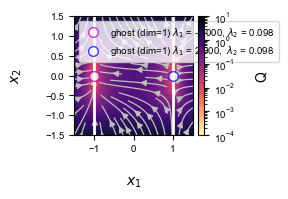

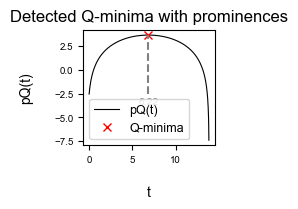

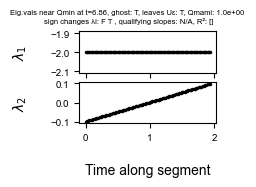

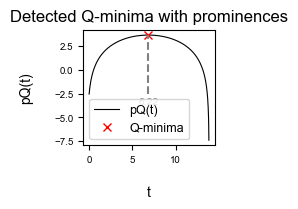

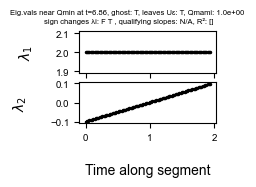

In [3]:
# 2D saddle node ghosts

def SN_2_0(t,z,para):
    mu1,mu2 = para

    mus = jnp.array([mu1,mu2])

    para_ = [mus,2,2,0]
    
    zdot = mod.SN_jk(t,z,para_)

    return zdot

parameters_SN_2_0 = [-1, 0.05]
IC1 = [-1,-5]
IC2 = [1,-5]

# simulate trajectory 
t_end = 30
dt = 0.02
timesteps = np.linspace(0,t_end,int(t_end/dt))
sol1 = solve_ivp(SN_2_0, (0, t_end), IC1, t_eval=timesteps, args=(parameters_SN_2_0,),method='RK45')
sol2 = solve_ivp(SN_2_0, (0, t_end), IC2, t_eval=timesteps, args=(parameters_SN_2_0,),method='RK45')

# run ghostID
Trj1=sol1.y.T
ghostSeq1, ctrlPlots1 = gid.ghostID(SN_2_0,parameters_SN_2_0,dt,Trj1,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# run ghostID
Trj2=sol2.y.T
ghostSeq2, ctrlPlots2 = gid.ghostID(SN_2_0,parameters_SN_2_0,dt,Trj2,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #


# phase space
xmin=-1.5;xmax=1.5
ymin=-1.5;ymax=1.5


Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(SN_2_0,parameters_SN_2_0,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return SN_2_0(t,z,parameters_SN_2_0)

U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 


ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.6,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol1.y[0,:],sol1.y[1,:],'-',color='ivory',lw=2)
ax.plot(sol2.y[0,:],sol2.y[1,:],'-',color='ivory',lw=2)

# plot ghost
for g in ghostSeq1:
    gx,gy = g["position"]
    ax.plot(
    gx, gy, 'ow',
    mec='m', markersize=7, alpha=0.75,
    label=(
        f'ghost (dim={g["dimension"]}) '
        + ", ".join(rf"$\lambda_{i+1}$ = {np.real(val):.3f}"
                    for i, val in enumerate(g["eigenvalues_qmin"]))
    )
    )

for g in ghostSeq2:
    gx,gy = g["position"]
    ax.plot(
    gx, gy, 'ow',
    mec='b', markersize=7, alpha=0.75,
    label=(
        f'ghost (dim={g["dimension"]})'
        + ", ".join(rf" $\lambda_{i+1}$ = {np.real(val):.3f}"
                    for i, val in enumerate(g["eigenvalues_qmin"]))
    )
    )

# plot Q-value
vmin = 1e-4 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.set_xlim(xmin,xmax); #ax.set_xticks([-4,-2,0])
ax.set_ylim(ymin,ymax);# ax.set_yticks([-4,-2,0])
ax.legend(fontsize=7)
if saveFigs: plt.savefig("SFig9a_PS.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots1[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots1[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)

axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')

plt.figure(fig)
plt.show()


# pQ timeseries and Q-minima
fig, ax = ctrlPlots2[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots2[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)

axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')

plt.figure(fig)
plt.show()

Ghost bifurcation diagram

In [4]:
showControlPlots = False # for selected parameter values below
n = 18
mu1_range = np.linspace(-1,1,n)
mu2 = 0.05

branch1 = []
branch2 = []
branch3 = []


for i in range(len(mu1_range)):

    t_end = 30
    dt = 0.02
    timesteps = np.linspace(0,t_end,int(t_end/dt))

    mu1 = mu1_range[i]
    parameters_SN_2_0 = [mu1, mu2]
    print(f"mu1: {mu1:.3f}")

    if mu1<0:
        IC1 = [-np.sqrt(-mu1),-1]
        IC2 = [np.sqrt(-mu1),-1]
  
        # simulate trajectory 

        sol1 = solve_ivp(SN_2_0, (0, t_end), IC1, t_eval=timesteps, args=(parameters_SN_2_0,),method='RK45')
        sol2 = solve_ivp(SN_2_0, (0, t_end), IC2, t_eval=timesteps, args=(parameters_SN_2_0,),method='RK45')

        # run ghostID
        Trj1=sol1.y.T
        ghostSeq1 = gid.ghostID(SN_2_0,parameters_SN_2_0,dt,Trj1,0.2,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":showControlPlots if mu1>0 else False,"qplot_xscale":"linear","ctrl_evplot":showControlPlots if mu1>0 else False}) #
        Trj2=sol2.y.T
        ghostSeq2 = gid.ghostID(SN_2_0,parameters_SN_2_0,dt,Trj2,0.2,peak_kwargs={"prominence":0}) #


        branch1.append(ghostSeq1[0])
        branch2.append(ghostSeq2[0])
        
    else:
              
        ghosts  = []
        for x2 in np.linspace(-1.3,0.3,50):
            IC = [-2,x2]

            sol = solve_ivp(SN_2_0, (0, t_end), IC, t_eval=timesteps, args=(parameters_SN_2_0,),method='RK45')
            # run ghostID
            Trj=sol.y.T
            ghostSeq = gid.ghostID(SN_2_0,parameters_SN_2_0,dt,Trj,0.2,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":False,"qplot_xscale":"linear","ctrl_evplot":showControlPlots if mu1>0.5 and mu1<0.7 else False}) #
            ghosts.append(ghostSeq[0] if len(ghostSeq)>0 else None)

        index_ghost_maxdim = np.argmax([g["dimension"] if g is not None else -1 for g in ghosts])
        ghost_maxdim = ghosts[index_ghost_maxdim]
        branch3.append(ghost_maxdim)


    


mu1: -1.000
mu1: -0.882
mu1: -0.765
mu1: -0.647
mu1: -0.529
mu1: -0.412
mu1: -0.294
mu1: -0.176
mu1: -0.059
mu1: 0.059
mu1: 0.176
mu1: 0.294
mu1: 0.412
mu1: 0.529
mu1: 0.647
mu1: 0.765
mu1: 0.882
mu1: 1.000


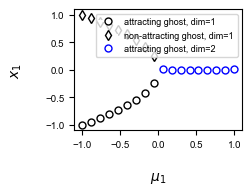

: 

In [ ]:
plt.figure(figsize=(5.5*inCm,4*inCm))
ax = plt.gca()

stability_branch1 = []
stability_branch2 = []

for g in branch1:
    eigvals = g["eigenvalues_qmin"]
    idx_max_abs_eigval = np.argmax(np.abs(eigvals))
    if np.real(eigvals[idx_max_abs_eigval])<0:
        stability_branch1.append("o")
    else:
        stability_branch1.append("d")

for g in branch2:
    eigvals = g["eigenvalues_qmin"]
    idx_max_abs_eigval = np.argmax(np.abs(eigvals))
    if np.real(eigvals[idx_max_abs_eigval])<0:
        stability_branch2.append("o")
    else:
        stability_branch2.append("d")

dimensions_branch1 = [g["dimension"] for g in branch1]
dimensions_branch2 = [g["dimension"] for g in branch2]
dimensions_branch3 = [g["dimension"] for g in branch3]
colors_branch1 = ['k' if dim==1 else 'b' for dim in dimensions_branch1]
colors_branch2 = ['k' if dim==1 else 'b' for dim in dimensions_branch2]
colors_branch3 = ['k' if dim==1 else 'b' for dim in dimensions_branch3]

for i in range(len(branch1)):
    marker = stability_branch1[i]
    color =  colors_branch1[i]
    ax.plot(mu1_range[i], branch1[i]["position"][0], marker=marker, color='w',mec=color, markersize=5, label=f"attracting ghost, dim={dimensions_branch1[i]}" if i==0 else "")
    marker = stability_branch2[i]
    color =  colors_branch2[i]
    ax.plot(mu1_range[i], branch2[i]["position"][0], marker=marker, color='w',mec=color, markersize=5, label=f"non-attracting ghost, dim={dimensions_branch2[i]}" if i==0 else "")
for i in range(len(branch3)):
    color =  colors_branch3[i]
    ax.plot(mu1_range[len(branch1)+i], branch3[i]["position"][0], marker='o', color='w', mec=color, markersize=5, label=f"attracting ghost, dim={dimensions_branch3[i]}" if i==0 else "")

ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$x_1$')
plt.legend(fontsize=6.5)
if saveFigs: plt.savefig("SFig9a_bifurcation.svg")
